## Assignment: Image recognition
- Alumno 1:
- Alumno 2:
- Alumno 3:

The goals of the assignment are:
* Develop proficiency in using Tensorflow/Keras for training Neural Nets (NNs).
* Put into practice the acquired knowledge to optimize the parameters and architecture of a feedforward Neural Net (ffNN), in the context of an image recognition problem.
* Put into practice NNs specially conceived for analysing images. Design and optimize the parameters of a Convolutional Neural Net (CNN) to deal with previous task.
* Train popular architectures from scratch (e.g., GoogLeNet, VGG, ResNet, ...), and compare the results with the ones provided by their pre-trained versions using transfer learning.

Follow the link below to download the classification data set  “xview_recognition”: [https://drive.upm.es/s/2DDPE2zHw5dbM3G](https://drive.upm.es/s/2DDPE2zHw5dbM3G)

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import requests
import zipfile

url = 'https://drive.upm.es/s/2DDPE2zHw5dbM3G/download'
zip_name = 'dataset.zip'

r = requests.get(url, stream=True)
with open(zip_name, 'wb') as f:
    for chunk in r.iter_content(chunk_size=1024):
        f.write(chunk)

if os.path.getsize(zip_name) < 10000:
    print(f"ERREUR : Le fichier {zip_name} est trop petit. Le lien est invalide ou nécessite une connexion.")
else:
    with zipfile.ZipFile(zip_name, 'r') as z:
        z.extractall(".")

    target_file = 'xview_ann_train.json'
    found_path = None

    for root, dirs, files in os.walk("."):
        if target_file in files:
            found_path = os.path.join(root, target_file)
            break

    if found_path:
        print(f"SUCCÈS : Fichier trouvé à : {found_path}")

        import json
        json_file = found_path

        with open(json_file) as ifs:
            json_data = json.load(ifs)
        print("Base de données chargée avec succès !")

    else:
        print(f"ERREUR : {target_file} reste introuvable après extraction.")

SUCCÈS : Fichier trouvé à : ./xview_recognition/xview_ann_train.json
Base de données chargée avec succès !


In [2]:
import tensorflow as tf

# Vérifie la présence de processeurs graphiques
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # Configuration pour ne pas allouer toute la mémoire d'un coup
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU activé : {len(gpus)} processeur(s) détecté(s)")
    except RuntimeError as e:
        print(e)
else:
    print("GPU non détecté. Activez l'accélérateur dans les réglages du notebook.")

2026-03-04 07:34:55.134036: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772609695.336766      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772609695.395787      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772609695.870551      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772609695.870620      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772609695.870623      24 computation_placer.cc:177] computation placer alr

GPU activé : 1 processeur(s) détecté(s)


In [3]:
import uuid
import numpy as np

class GenericObject:
    """
    Generic object data.
    """
    def __init__(self):
        self.id = uuid.uuid4()
        self.bb = (-1, -1, -1, -1)
        self.category= -1
        self.score = -1

class GenericImage:
    """
    Generic image data.
    """
    def __init__(self, filename):
        self.filename = filename
        self.tile = np.array([-1, -1, -1, -1])  # (pt_x, pt_y, pt_x+width, pt_y+height)
        self.objects = list([])

    def add_object(self, obj: GenericObject):
        self.objects.append(obj)

In [4]:
categories = {0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}

In [5]:
!pip install rasterio

In [6]:
import warnings
import rasterio
import numpy as np

def load_geoimage(filename):
    warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)
    src_raster = rasterio.open('./xview_recognition/'+filename, 'r')
    # RasterIO to OpenCV (see inconsistencies between libjpeg and libjpeg-turbo)
    input_type = src_raster.profile['dtype']
    input_channels = src_raster.count
    img = np.zeros((src_raster.height, src_raster.width, src_raster.count), dtype=input_type)
    for band in range(input_channels):
        img[:, :, band] = src_raster.read(band+1)
    return img

#### Training
Design and train a ffNN to deal with the “xview_recognition” classification task.

In [7]:
import json

# Load database
json_file = './xview_recognition/xview_ann_train.json'
with open(json_file) as ifs:
    json_data = json.load(ifs)
ifs.close()

In [8]:
import numpy as np

counts = dict.fromkeys(categories.values(), 0)
anns = []
for json_img, json_ann in zip(json_data['images'].values(), json_data['annotations'].values()):
    image = GenericImage(json_img['filename'])
    image.tile = np.array([0, 0, json_img['width'], json_img['height']])
    obj = GenericObject()
    obj.bb = (int(json_ann['bbox'][0]), int(json_ann['bbox'][1]), int(json_ann['bbox'][2]), int(json_ann['bbox'][3]))
    obj.category = json_ann['category_id']
    # Resampling strategy to reduce training time
    counts[obj.category] += 1
    image.add_object(obj)
    anns.append(image)
print(counts)
labels = [img.objects[0].category for img in anns]

{'Cargo plane': 635, 'Small car': 3324, 'Bus': 1768, 'Truck': 2210, 'Motorboat': 1069, 'Fishing vessel': 706, 'Dump truck': 1236, 'Excavator': 789, 'Building': 3594, 'Helipad': 111, 'Storage tank': 1469, 'Shipping container': 1523, 'Pylon': 312}


In [9]:
batch_size = 128
n_models = 3

In [10]:
from sklearn.model_selection import train_test_split

anns_train, anns_valid = train_test_split(anns, test_size=0.15, random_state=42, shuffle=True, stratify=labels)
print('Number of training images: ' + str(len(anns_train)))
print('Number of validation images: ' + str(len(anns_valid)))

Number of training images: 15934
Number of validation images: 2812


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (Input, Dense, BatchNormalization,
                                     Activation, Dropout, Rescaling)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Nadam
from tensorflow.keras.losses import CategoricalFocalCrossentropy

IMG_SIZE = 96

def create_transfer_model(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                           num_classes=13, batch_size=128, train_size=None):
    img_input = Input(shape=input_shape, name='img_input')

    # EfficientNetB0 attend [0,255] ; le générateur produit [0,1]
    x = Rescaling(255.0)(img_input)

    backbone = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling='avg'       
    )
    backbone.trainable = False  # Phase 1 : backbone gelé

    # training=False : BN internes du backbone en mode inférence
    # (préserve les stats ImageNet pendant les 2 phases)
    x = backbone(x, training=False)

    # Tête — 1 seule couche dense (vs 3 × 1024/512 avant)
    x = Dense(256, kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation('swish')(x)
    x = Dropout(0.3)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=img_input, outputs=outputs)

    decay_steps_p1 = 20 * (train_size // batch_size) if train_size else 1000

    model.compile(
        optimizer=Nadam(
            learning_rate=tf.keras.optimizers.schedules.CosineDecay(
                initial_learning_rate=1e-3,
                decay_steps=decay_steps_p1,
                alpha=0.1
            ),
            weight_decay=1e-4
        ),
        loss=CategoricalFocalCrossentropy(alpha=0.25, gamma=2.0),
        metrics=['accuracy']
    )
    return model

In [12]:
#from tensorflow.keras.optimizers import Adam
#
## Learning rate is changed to 0.001
#opt = Adam(learning_rate=lr_schedule, beta_1=0.9, beta_2=0.999, epsilon=1e-8, amsgrad=True, clipnorm=1.0)
#model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [13]:
from tensorflow.keras.callbacks import TerminateOnNaN, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Callbacks
model_checkpoint = ModelCheckpoint('model.keras', monitor='val_accuracy', verbose=1, save_best_only=True)
#reduce_lr = ReduceLROnPlateau('val_accuracy', factor=0.1, patience=10, verbose=1)
early_stop = EarlyStopping('val_accuracy', patience=10, verbose=1)
terminate = TerminateOnNaN()
callbacks = [model_checkpoint, early_stop, terminate]

In [ ]:
import numpy as np
import tensorflow as tf

def generator_images(objs, batch_size, do_shuffle=False, class_weights=None):
    """
    Générateur produisant des batches d'images redimensionnées et leurs labels.
    objs : liste de tuples (filename, obj)
    """
    while True:
        if do_shuffle:
            np.random.shuffle(objs)
        groups = [objs[i:i+batch_size] for i in range(0, len(objs), batch_size)]

        for group in groups:
            images, labels, sample_weights = [], [], []
            for filename, obj in group:
                img = load_geoimage(filename)
                img_tensor = tf.convert_to_tensor(img)
                img_tensor = tf.image.convert_image_dtype(img_tensor, tf.float32)
                img_resized = tf.image.resize(img_tensor, [IMG_SIZE, IMG_SIZE], method='bicubic')
                images.append(img_resized.numpy())

                cat_idx = list(categories.values()).index(obj.category)
                prob = np.zeros(len(categories))
                prob[cat_idx] = 1
                labels.append(prob)

                if class_weights is not None:
                    sample_weights.append(class_weights[cat_idx])

            images = np.array(images).astype(np.float32)
            labels = np.array(labels).astype(np.float32)

            if class_weights is not None:
                sample_weights = np.array(sample_weights).astype(np.float32)
                yield images, labels, sample_weights
            else:
                yield images, labels

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

objs_train = [(ann.filename, obj) for ann in anns_train for obj in ann.objects]
objs_valid = [(ann.filename, obj) for ann in anns_valid for obj in ann.objects]

print('Calcul des poids de classes...')
y_train_indices = [list(categories.values()).index(obj.category) for _, obj in objs_train]
weights = compute_class_weight('balanced', classes=np.unique(y_train_indices), y=y_train_indices)
class_weights = dict(enumerate(weights))

# Ajustements manuels (exemple)
class_weights[3] *= 1.5   # Truck
class_weights[9] *= 1.5   # Helipad

batch_size = 128

train_generator = generator_images(objs_train, batch_size, do_shuffle=True, class_weights=class_weights)
valid_generator = generator_images(objs_valid, batch_size, do_shuffle=False)


Calcul des poids de classes...


In [ ]:
n_models = 3
train_size = len(objs_train)

models = []
for i in range(n_models):
    print(f"Création du modèle {i+1}/{n_models}")
    model = create_transfer_model(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        num_classes=len(categories),
        batch_size=batch_size,
        train_size=train_size
    )
    models.append(model)

Création du modèle 1/3


I0000 00:00:1772609733.189124      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Création du modèle 2/3
Création du modèle 3/3


In [ ]:
import math
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

epochs_p1 = 20   # backbone gelé — convergence rapide de la tête
epochs_p2 = 30   # fine-tuning partiel
train_steps = math.ceil(len(objs_train) / batch_size)
valid_steps = math.ceil(len(objs_valid) / batch_size)

for i, model in enumerate(models):
    print(f"\n=== Modèle {i+1}/{n_models} ===")

    # ── Phase 1 : tête seule ──────────────────────────────────────────
    print("Phase 1 : backbone gelé")
    ckpt = ModelCheckpoint(f'model_{i}.keras', monitor='val_accuracy',
                           save_best_only=True, verbose=1)
    model.fit(
        train_generator,
        steps_per_epoch=train_steps,
        validation_data=valid_generator,
        validation_steps=valid_steps,
        epochs=epochs_p1,
        callbacks=[ckpt, EarlyStopping(patience=8, restore_best_weights=True, verbose=1)],
        verbose=1
    )

    # ── Phase 2 : fine-tuning des 30 dernières couches du backbone ────
    print("Phase 2 : fine-tuning partiel")
    backbone = next(l for l in model.layers
                    if isinstance(l, tf.keras.Model))
    backbone.trainable = True
    # On gèle tout sauf les 30 dernières couches du backbone
    for layer in backbone.layers[:-30]:
        layer.trainable = False

    decay_steps_p2 = epochs_p2 * (len(objs_train) // batch_size)
    model.compile(
        optimizer=Nadam(
            learning_rate=tf.keras.optimizers.schedules.CosineDecay(
                initial_learning_rate=1e-5,   # LR très bas pour ne pas détruire les features
                decay_steps=decay_steps_p2,
                alpha=0.01
            ),
            weight_decay=1e-4
        ),
        loss=CategoricalFocalCrossentropy(alpha=0.25, gamma=2.0),
        metrics=['accuracy']
    )

    ckpt2 = ModelCheckpoint(f'model_{i}.keras', monitor='val_accuracy',
                            save_best_only=True, verbose=1)
    model.fit(
        train_generator,
        steps_per_epoch=train_steps,
        validation_data=valid_generator,
        validation_steps=valid_steps,
        epochs=epochs_p2,
        callbacks=[ckpt2, EarlyStopping(patience=10, restore_best_weights=True, verbose=1)],
        verbose=1
    )

Entraînement des modèles

--- Modèle 1/3 ---
Epoch 1/50


I0000 00:00:1772609750.355674      69 service.cc:152] XLA service 0x7d64bc409ed0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772609750.355724      69 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772609752.674571      69 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772609782.912434      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1898 - loss: 0.5129   
Epoch 1: val_accuracy improved from -inf to 0.08890, saving model to model_0.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 219s 1s/step - accuracy: 0.1901 - loss: 0.5125 - val_accuracy: 0.0889 - val_loss: 0.8374
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 977ms/step - accuracy: 0.3023 - loss: 0.3773
Epoch 2: val_accuracy improved from 0.08890 to 0.18883, saving model to model_0.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.3024 - loss: 0.3773 - val_accuracy: 0.1888 - val_loss: 0.6456
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 949ms/step - accuracy: 0.3590 - loss: 0.3300
Epoch 3: val_accuracy improved from 0.18883 to 0.22048, saving model to model_0.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.3591 - loss: 0.3298 - val_accuracy: 0.2205 - val_loss: 0.5693
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 926ms/step - accuracy: 0.4390 - loss: 0.2826
Epoch 4: val_accuracy improved from 0.22048 to 0.3

#### Validation
Compute validation metrics.

In [18]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

def draw_confusion_matrix(cm, categories):
    # Draw confusion matrix
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.colormaps['Blues'])
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]), xticklabels=list(categories.values()), yticklabels=list(categories.values()), ylabel='Annotation', xlabel='Prediction')
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    # Loop over data dimensions and create text annotations
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], '.2f'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black", fontsize=int(20-pow(len(categories), 0.5)))
    fig.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import tensorflow as tf

y_true, y_pred = [], []
all_images = []
temp_true_labels = []

print("Chargement des données de validation...")
for ann in anns_valid:
    image_raw = load_geoimage(ann.filename)
    image_tensor = tf.convert_to_tensor(image_raw)
    image_tensor = tf.image.convert_image_dtype(image_tensor, tf.float32)
    image_resized = tf.image.resize(image_tensor, [IMG_SIZE, IMG_SIZE], method='bicubic')

    for obj_pred in ann.objects:
        all_images.append(image_resized.numpy())
        temp_true_labels.append(obj_pred.category)

if all_images:
    X_valid = np.array(all_images)
    print(f"Lancement de la prédiction sur {len(X_valid)} objets...")

    # Moyenne des prédictions des 3 modèles
    all_predictions = np.mean([
        model.predict(X_valid, batch_size=128, verbose=1) for model in models
    ], axis=0)

    category_names = list(categories.values())
    for i in range(len(all_predictions)):
        pred_category = category_names[np.argmax(all_predictions[i])]
        y_true.append(temp_true_labels[i])
        y_pred.append(pred_category)

Chargement des données de validation...
Lancement de la prédiction sur 2812 objets...
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step


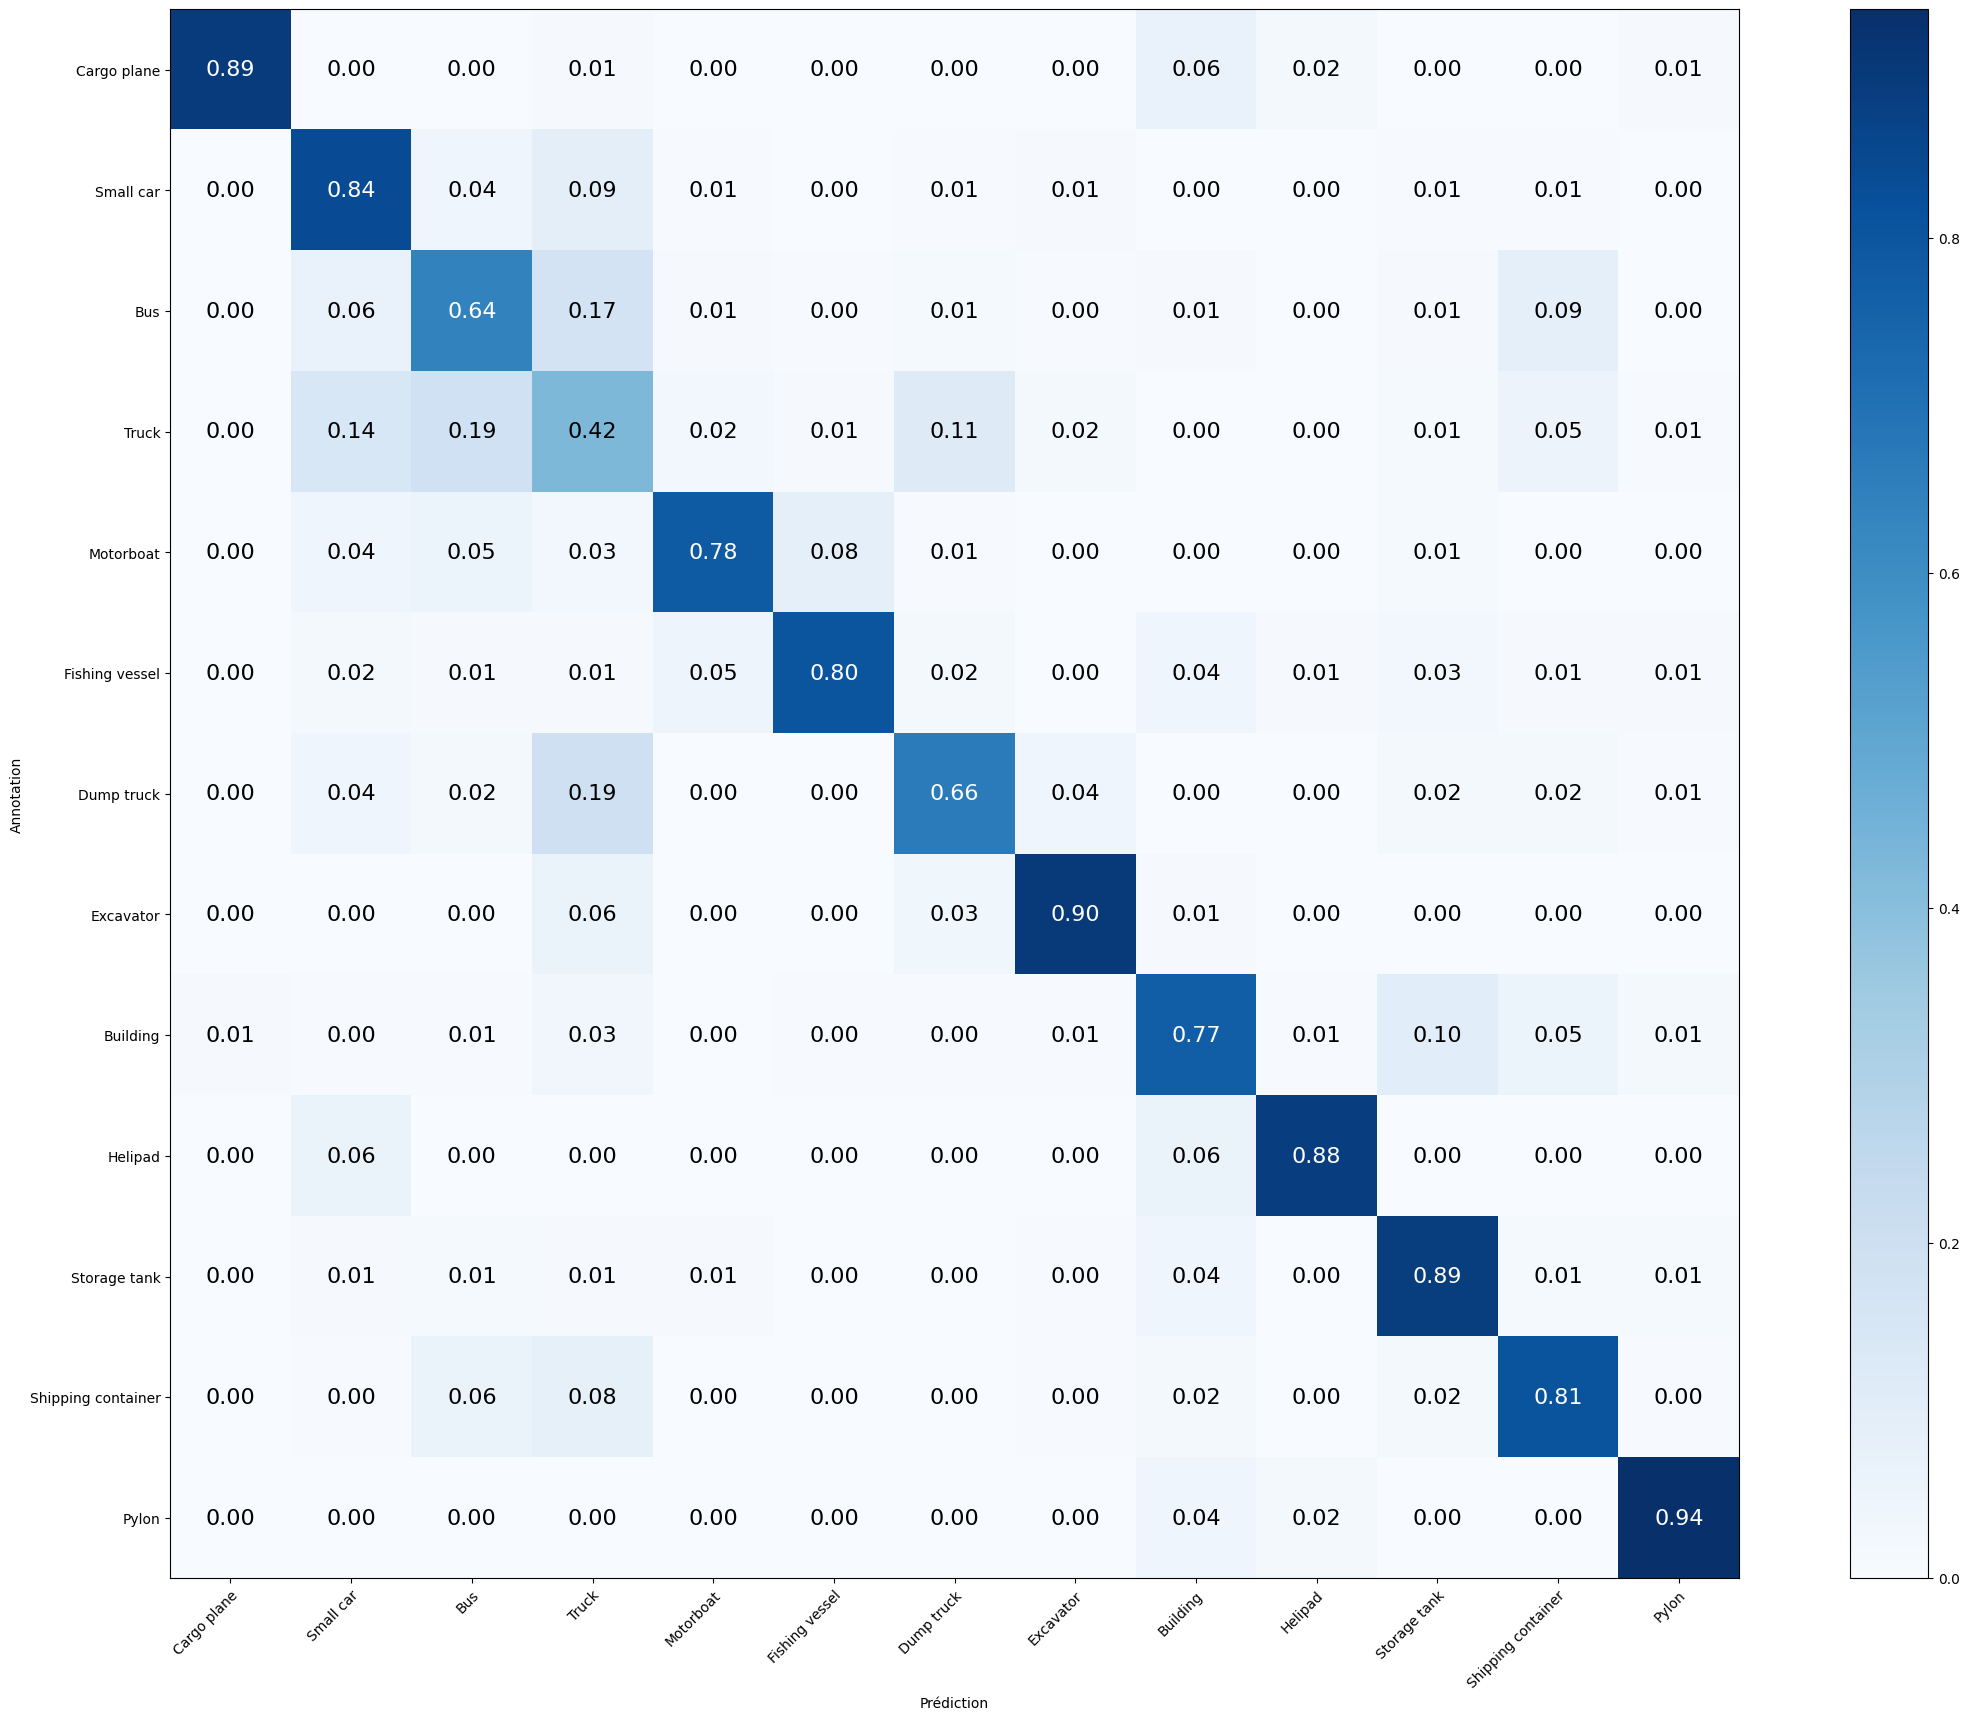

In [20]:
from sklearn.metrics import confusion_matrix

def draw_confusion_matrix(cm, categories):
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm_norm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm_norm, interpolation='nearest', cmap=plt.colormaps['Blues'])
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]),
           xticklabels=list(categories.values()), yticklabels=list(categories.values()),
           ylabel='Annotation', xlabel='Prédiction')
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    thresh = cm_norm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm_norm[i, j], '.2f'),
                    ha="center", va="center",
                    color="white" if cm_norm[i, j] > thresh else "black",
                    fontsize=int(20-pow(len(categories), 0.5)))
    fig.tight_layout()
    plt.show()

# Calcul et affichage
cm = confusion_matrix(y_true, y_pred, labels=list(categories.values()))
draw_confusion_matrix(cm, categories)

In [21]:
import numpy as np

# Compute the accuracy
correct_samples_class = np.diag(cm).astype(float)
total_samples_class = np.sum(cm, axis=1).astype(float)
total_predicts_class = np.sum(cm, axis=0).astype(float)
print('Mean Accuracy: %.3f%%' % (np.sum(correct_samples_class) / np.sum(total_samples_class) * 100))
acc = correct_samples_class / np.maximum(total_samples_class, np.finfo(np.float64).eps)
print('Mean Recall: %.3f%%' % (acc.mean() * 100))
acc = correct_samples_class / np.maximum(total_predicts_class, np.finfo(np.float64).eps)
print('Mean Precision: %.3f%%' % (acc.mean() * 100))
for idx in range(len(categories)):
    # True/False Positives (TP/FP) refer to the number of predicted positives that were correct/incorrect.
    # True/False Negatives (TN/FN) refer to the number of predicted negatives that were correct/incorrect.
    tp = cm[idx, idx]
    fp = sum(cm[:, idx]) - tp
    fn = sum(cm[idx, :]) - tp
    tn = sum(np.delete(sum(cm) - cm[idx, :], idx))
    # True Positive Rate: proportion of real positive cases that were correctly predicted as positive.
    recall = tp / np.maximum(tp+fn, np.finfo(np.float64).eps)
    # Precision: proportion of predicted positive cases that were truly real positives.
    precision = tp / np.maximum(tp+fp, np.finfo(np.float64).eps)
    # True Negative Rate: proportion of real negative cases that were correctly predicted as negative.
    specificity = tn / np.maximum(tn+fp, np.finfo(np.float64).eps)
    # Dice coefficient refers to two times the intersection of two sets divided by the sum of their areas.
    # Dice = 2 |A∩B| / (|A|+|B|) = 2 TP / (2 TP + FP + FN)
    f1_score = 2 * ((precision * recall) / np.maximum(precision+recall, np.finfo(np.float64).eps))
    print('> %s: Recall: %.3f%% Precision: %.3f%% Specificity: %.3f%% Dice: %.3f%%' % (list(categories.values())[idx], recall*100, precision*100, specificity*100, f1_score*100))

Mean Accuracy: 74.858%
Mean Recall: 78.630%
Mean Precision: 75.135%
> Cargo plane: Recall: 89.474% Precision: 95.506% Specificity: 99.853% Dice: 92.391%
> Small car: Recall: 83.567% Precision: 82.574% Specificity: 96.195% Dice: 83.068%
> Bus: Recall: 63.774% Precision: 59.298% Specificity: 95.446% Dice: 61.455%
> Truck: Recall: 42.470% Precision: 44.762% Specificity: 92.984% Dice: 43.586%
> Motorboat: Recall: 78.125% Precision: 86.207% Specificity: 99.246% Dice: 81.967%
> Fishing vessel: Recall: 80.189% Precision: 81.731% Specificity: 99.298% Dice: 80.952%
> Dump truck: Recall: 66.486% Precision: 69.886% Specificity: 97.982% Dice: 68.144%
> Excavator: Recall: 89.831% Precision: 80.916% Specificity: 99.072% Dice: 85.141%
> Building: Recall: 76.994% Precision: 93.258% Specificity: 98.680% Dice: 84.350%
> Helipad: Recall: 88.235% Precision: 68.182% Specificity: 99.750% Dice: 76.923%
> Storage tank: Recall: 88.636% Precision: 71.956% Specificity: 97.068% Dice: 79.430%
> Shipping container:

#### Testing
Try to improve the results provided in the competition.

In [22]:
import os
import numpy as np

anns = []
root_dir = './xview_recognition/'
test_dir = os.path.join(root_dir, 'xview_test')
for (dirpath, dirnames, filenames) in os.walk(test_dir):
    for filename in filenames:
        rel_dir = os.path.relpath(dirpath, root_dir)
        clean_filename = os.path.join(rel_dir, filename)
        image = GenericImage(clean_filename)
        image.tile = np.array([0, 0, 224, 224])
        obj = GenericObject()
        obj.bb = (0, 0, 224, 224)
        obj.category = os.path.basename(dirpath)
        image.add_object(obj)
        anns.append(image)
print('Number of testing images: ' + str(len(anns)))

Number of testing images: 2365


In [ ]:
import numpy as np
import tensorflow as tf

predictions_data = {"images": {}, "annotations": {}}
all_test_images = []
metadata = [] 
ann_id = 0

print("Préparation des images de test...")
for idx, ann in enumerate(anns):
    image_data = {
        "image_id": ann.filename.split('/')[-1],
        "filename": ann.filename,
        "width": int(ann.tile[2]),
        "height": int(ann.tile[3])
    }
    predictions_data["images"][idx] = image_data

    image_raw = load_geoimage(ann.filename)
    image_tensor = tf.convert_to_tensor(image_raw)
    image_tensor = tf.image.convert_image_dtype(image_tensor, tf.float32)
    image_resized = tf.image.resize(image_tensor, [IMG_SIZE, IMG_SIZE], method='bicubic')
    img_final = image_resized.numpy()

    for obj_pred in ann.objects:
        all_test_images.append(img_final)
        metadata.append({
            "image_id": ann.filename.split('/')[-1],
            "bbox": [int(x) for x in obj_pred.bb]
        })

if all_test_images:
    X_test = np.array(all_test_images)
    print(f"Prédiction en cours sur {len(X_test)} détections...")
    # Moyenne des prédictions des 3 modèles
    all_preds = np.mean([
        model.predict(X_test, batch_size=128, verbose=1) for model in models
    ], axis=0)

    category_names = list(categories.values())
    for i, pred in enumerate(all_preds):
        pred_category = category_names[np.argmax(pred)]
        predictions_data["annotations"][ann_id] = {
            "image_id": metadata[i]["image_id"],
            "category_id": pred_category,
            "bbox": metadata[i]["bbox"]
        }
        ann_id += 1

print("Test terminé.")

Préparation des images de test...
Prédiction en cours sur 2365 détections...
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 285ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step
Test terminé.


In [24]:
#for i, model in enumerate(models):
#    model.load_weights(f'model_{i}.keras')

In [25]:
import json
with open('prediction.json', 'w') as f:
    json.dump(predictions_data, f)